In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import girvan_newman

In [5]:
df = pd.read_csv('social_media_data.csv')
df.head(10)

,text,user,location,date,likes,comments,shares,brand
0,Nike shoes are amazing! #Nike #Running,user1,Mumbai,2024-01-01,120,30,15,Nike
1,Adidas new collection is great #Adidas,user2,Delhi,2024-01-02,85,20,10,Adidas
2,I love my Nike trainers best ever!,user3,Mumbai,2024-01-03,200,50,25,Nike
3,Adidas vs Nike which is better?,user4,Pune,2024-01-04,60,10,5,Adidas
4,Nike Air Max release today #Nike #Shoes,user5,Delhi,2024-01-05,175,45,20,Nike
5,Worst experience with Adidas support,user6,Mumbai,2024-01-06,30,5,2,Adidas
6,Running with Nike feels incredible,user7,Chennai,2024-01-07,140,35,18,Nike
7,Adidas ultraboost very comfortable shoes,user8,Pune,2024-01-08,90,25,12,Adidas
8,Nike just released new gear #Nike,user9,Delhi,2024-01-09,160,40,22,Nike
9,Adidas collaboration is fire #Fashion,user10,Mumbai,2024-01-10,110,28,14,Adidas


In [3]:
G = nx.Graph();

In [4]:
for user in df['user']:
    G.add_node(user);

In [7]:
for brand in df['brand'].unique():
    temp = df[ df['brand'] == brand ]
    users = temp['user'].tolist()
    print(users)
    for i in range(len(users)):
        for j in range(len(users)):
            if i!=j :
                G.add_edge(users[i],users[j])

['user1', 'user3', 'user5', 'user7', 'user9']
['user2', 'user4', 'user6', 'user8', 'user10']


In [8]:
result = girvan_newman(G)
result

<generator object girvan_newman at 0x000001FD6C426880>

In [9]:
first_split = next(result)
print(first_split)

({'user1'}, {'user6', 'user8', 'user10', 'user4', 'user2'}, {'user9', 'user3', 'user5', 'user7'})


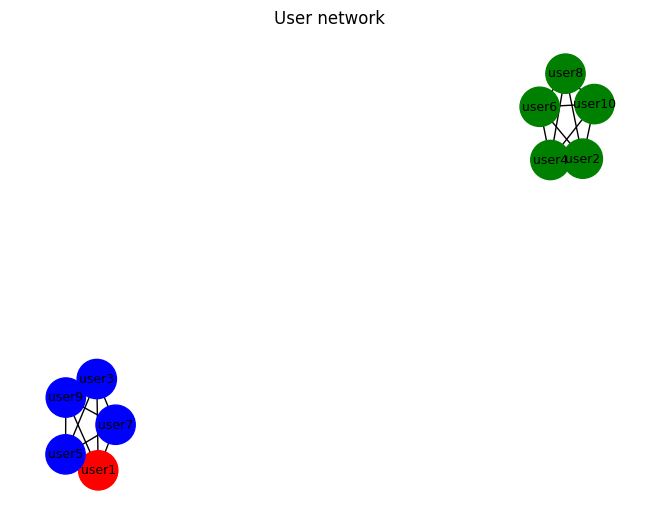

In [26]:
pos = nx.spring_layout(G)
color_map =[]
for nodes in G.nodes():
    if nodes in first_split[0]:
        color_map.append('red')
    elif nodes in first_split[1]:
        color_map.append('green')
    else:
        color_map.append('blue')

nx.draw(G,pos,node_color=color_map,node_size=800 ,font_size = 9, with_labels=True)

plt.title('User network')
plt.show()